#  Emotion Detection from Voice — RAVDESS Dataset
## Étape 1 : Visualisation & Exploration des données

**Dataset :** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)  
**Objectif :** Explorer la structure, visualiser les distributions et les features audio

---
##  Cellule 1 — Imports

In [2]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Audio, display

# Style global
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

print(' Imports OK')

 Imports OK


---
##  Cellule 2 — Chargement et parsing du dataset

In [4]:
EMOTIONS = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

INTENSITY = {'01': 'normal', '02': 'strong'}
STATEMENT = {'01': 'kids are talking', '02': 'dogs are sitting'}


RAVDESS_PATH = '/kaggle/input/datasets/elouardaniilyasse/ravdess/RAVDESS'

records = []

for actor_folder in sorted(os.listdir(RAVDESS_PATH)):
    actor_path = os.path.join(RAVDESS_PATH, actor_folder)
    if not os.path.isdir(actor_path):
        continue

    for filename in os.listdir(actor_path):
        if not filename.endswith('.wav'):
            continue

        parts = filename.replace('.wav', '').split('-')
        if len(parts) < 7:
            continue  # ignorer fichiers mal formés

        actor_id     = int(parts[6])
        emotion_code = parts[2]
        intensity    = parts[3]
        statement    = parts[4]

        records.append({
            'path'      : os.path.join(actor_path, filename),
            'emotion'   : EMOTIONS.get(emotion_code, 'unknown'),
            'intensity' : INTENSITY.get(intensity, 'unknown'),
            'statement' : STATEMENT.get(statement, 'unknown'),
            'actor'     : actor_id,
            'gender'    : 'female' if actor_id % 2 == 0 else 'male',
            'filename'  : filename
        })

df = pd.DataFrame(records)
print(f' {len(df)} fichiers trouvés — {df["actor"].nunique()} acteurs')
print(f'   Émotions : {sorted(df["emotion"].unique())}')
df.head(10)

 1440 fichiers trouvés — 24 acteurs
   Émotions : ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


,path,emotion,intensity,statement,actor,gender,filename
0,/kaggle/input/datasets/elouardaniilyasse/ravde...,calm,normal,dogs are sitting,1,male,03-01-02-01-02-02-01.wav
1,/kaggle/input/datasets/elouardaniilyasse/ravde...,neutral,normal,kids are talking,1,male,03-01-01-01-01-02-01.wav
2,/kaggle/input/datasets/elouardaniilyasse/ravde...,sad,strong,kids are talking,1,male,03-01-04-02-01-02-01.wav
3,/kaggle/input/datasets/elouardaniilyasse/ravde...,calm,strong,dogs are sitting,1,male,03-01-02-02-02-01-01.wav
4,/kaggle/input/datasets/elouardaniilyasse/ravde...,calm,normal,dogs are sitting,1,male,03-01-02-01-02-01-01.wav
5,/kaggle/input/datasets/elouardaniilyasse/ravde...,fearful,normal,dogs are sitting,1,male,03-01-06-01-02-02-01.wav
6,/kaggle/input/datasets/elouardaniilyasse/ravde...,happy,strong,kids are talking,1,male,03-01-03-02-01-02-01.wav
7,/kaggle/input/datasets/elouardaniilyasse/ravde...,happy,normal,dogs are sitting,1,male,03-01-03-01-02-01-01.wav
8,/kaggle/input/datasets/elouardaniilyasse/ravde...,disgust,strong,kids are talking,1,male,03-01-07-02-01-02-01.wav
9,/kaggle/input/datasets/elouardaniilyasse/ravde...,angry,normal,kids are talking,1,male,03-01-05-01-01-02-01.wav


---
##  Cellule 3 — Statistiques rapides

In [5]:
print('=== Répartition des émotions ===')
print(df['emotion'].value_counts())

print('\n=== Répartition par genre ===')
print(df['gender'].value_counts())

ratio = df['emotion'].value_counts().max() / df['emotion'].value_counts().min()
print(f'\n Ratio déséquilibre max/min : {ratio:.2f}x')
if ratio < 1.5:
    print('   → Dataset bien équilibré ')
else:
    print('   → Attention au déséquilibre ')

=== Répartition des émotions ===
emotion
calm         192
sad          192
fearful      192
happy        192
angry        192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

=== Répartition par genre ===
gender
male      720
female    720
Name: count, dtype: int64

 Ratio déséquilibre max/min : 2.00x
   → Attention au déséquilibre 


---
##  Cellule 4 — Distribution des émotions (globale + par genre)

/tmp/ipykernel_58/2379289336.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', order=order, palette='viridis', ax=axes[0])


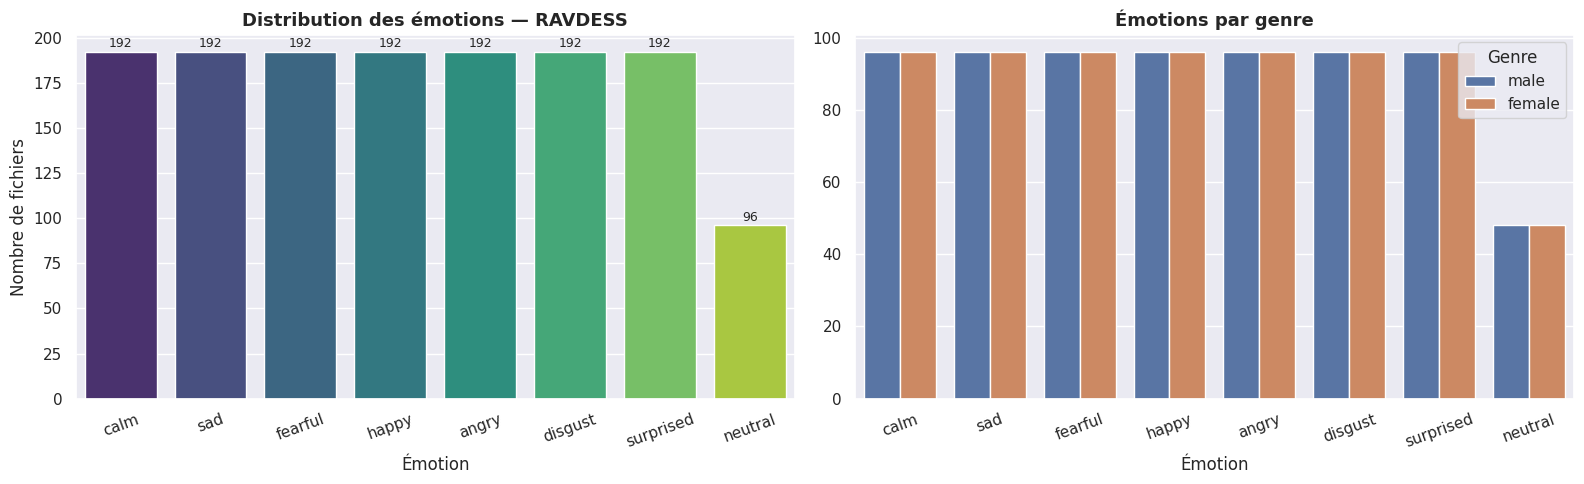

 Sauvegardé : distribution_emotions.png


In [6]:
order = df['emotion'].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Globale ---
sns.countplot(data=df, x='emotion', order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution des émotions — RAVDESS', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Émotion')
axes[0].set_ylabel('Nombre de fichiers')
axes[0].tick_params(axis='x', rotation=20)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=9
    )

# --- Par genre ---
sns.countplot(data=df, x='emotion', hue='gender', order=order,
              palette={'male': '#4C72B0', 'female': '#DD8452'}, ax=axes[1])
axes[1].set_title('Émotions par genre', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Émotion')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Genre')

plt.tight_layout()
plt.savefig('distribution_emotions.png', bbox_inches='tight')
plt.show()
print(' Sauvegardé : distribution_emotions.png')

---
##  Cellule 5 — Distribution des durées (méthode rapide)

Calcul des durées...
count    1440.00
mean        3.70
std         0.34
min         2.94
25%         3.47
50%         3.67
75%         3.87
max         5.27
Name: duration, dtype: float64


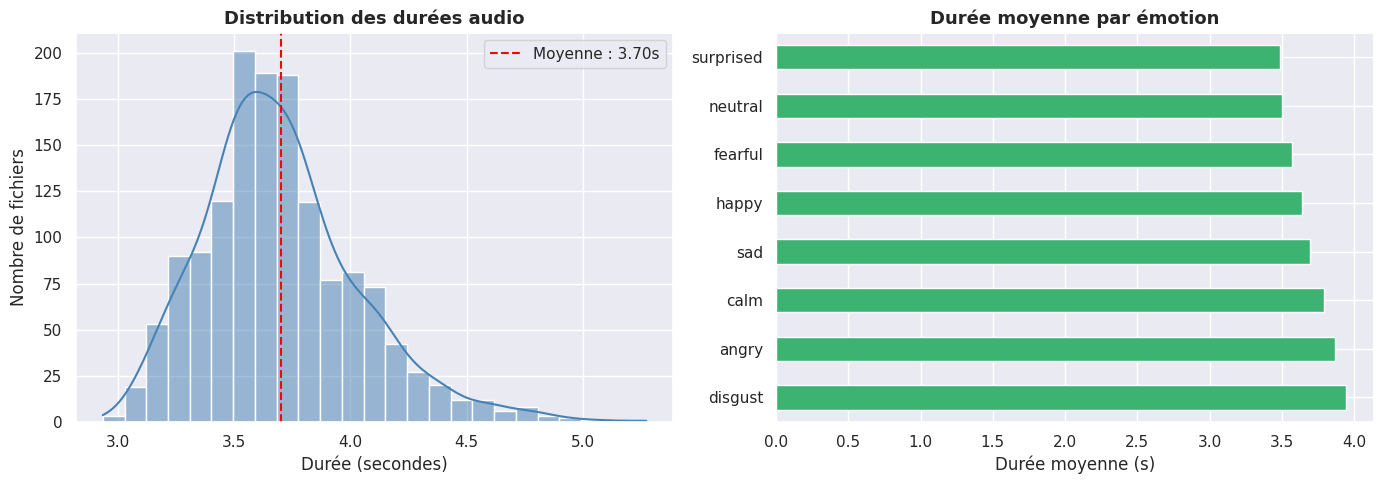

 Sauvegardé : distribution_durees.png


In [7]:
# librosa.get_duration évite de charger tout l'audio en mémoire
print('Calcul des durées...')
df['duration'] = df['path'].apply(lambda p: librosa.get_duration(path=p))

print(df['duration'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
sns.histplot(df['duration'], bins=25, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df['duration'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["duration"].mean():.2f}s')
axes[0].set_title('Distribution des durées audio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Durée (secondes)')
axes[0].set_ylabel('Nombre de fichiers')
axes[0].legend()

# Durée moyenne par émotion
dur_emotion = df.groupby('emotion')['duration'].mean().sort_values(ascending=False)
dur_emotion.plot(kind='barh', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Durée moyenne par émotion', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Durée moyenne (s)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribution_durees.png', bbox_inches='tight')
plt.show()
print(' Sauvegardé : distribution_durees.png')

---
##  Cellule 6 — Waveform + Mel-Spectrogramme + MFCC (angry)

Fichier   : 03-01-05-01-01-02-01.wav
Durée     : 3.94 secondes
Sr        : 16000 Hz | Échantillons : 62,997


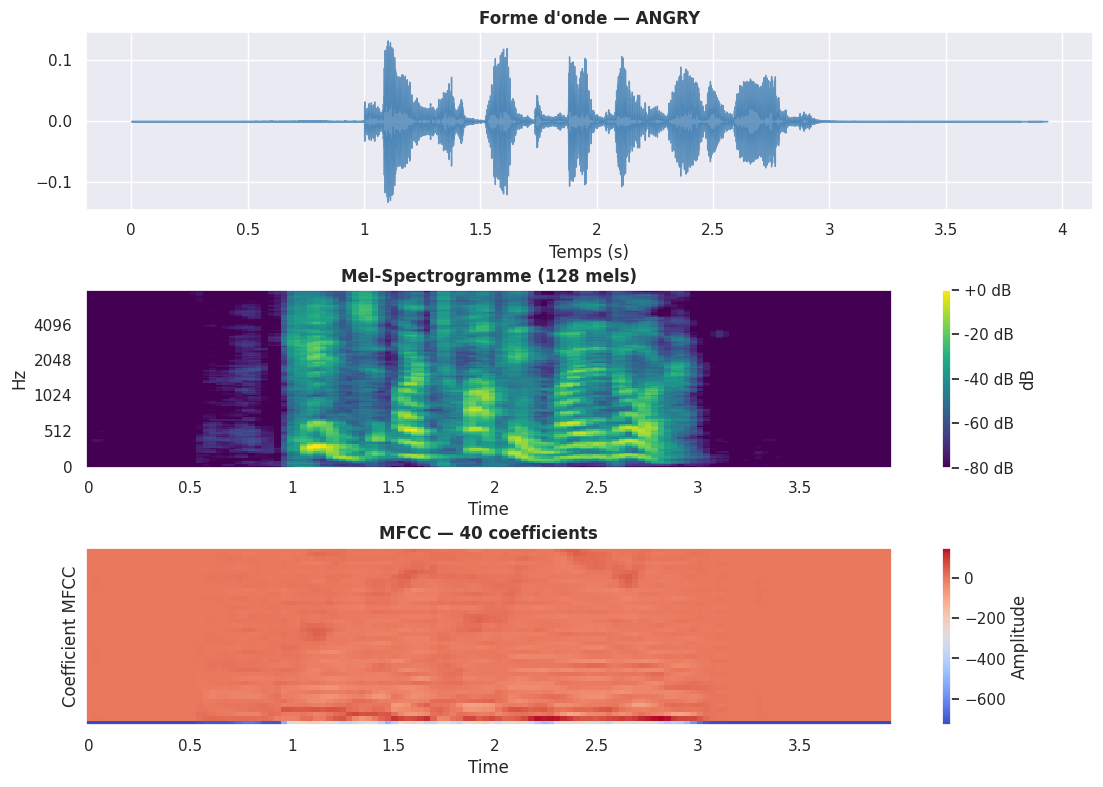

 Sauvegardé : visualisation_angry.png


In [8]:
EMOTION_VIZ = 'angry'
SR = 16000

sample_path = df[df['emotion'] == EMOTION_VIZ].iloc[0]['path']
audio, sr   = librosa.load(sample_path, sr=SR)

print(f'Fichier   : {os.path.basename(sample_path)}')
print(f'Durée     : {len(audio)/sr:.2f} secondes')
print(f'Sr        : {sr} Hz | Échantillons : {len(audio):,}')

display(Audio(audio, rate=sr))

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# --- Waveform ---
ax0 = fig.add_subplot(gs[0])
librosa.display.waveshow(audio, sr=sr, ax=ax0, color='steelblue', alpha=0.8)
ax0.set_title(f"Forme d'onde — {EMOTION_VIZ.upper()}", fontweight='bold')
ax0.set_xlabel('Temps (s)')

# --- Mel-spectrogramme ---
ax1 = fig.add_subplot(gs[1])
mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
mel_db = librosa.power_to_db(mel, ref=np.max)
img1   = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax1, cmap='viridis')
fig.colorbar(img1, ax=ax1, format='%+2.0f dB', label='dB')
ax1.set_title('Mel-Spectrogramme (128 mels)', fontweight='bold')

# --- MFCC ---
ax2  = fig.add_subplot(gs[2])
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
img2 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax2, cmap='coolwarm')
fig.colorbar(img2, ax=ax2, label='Amplitude')
ax2.set_title('MFCC — 40 coefficients', fontweight='bold')
ax2.set_ylabel('Coefficient MFCC')

plt.savefig(f'visualisation_{EMOTION_VIZ}.png', bbox_inches='tight')
plt.show()
print(f' Sauvegardé : visualisation_{EMOTION_VIZ}.png')

---
##  Cellule 7 — Comparaison de 4 émotions (waveform + mel)

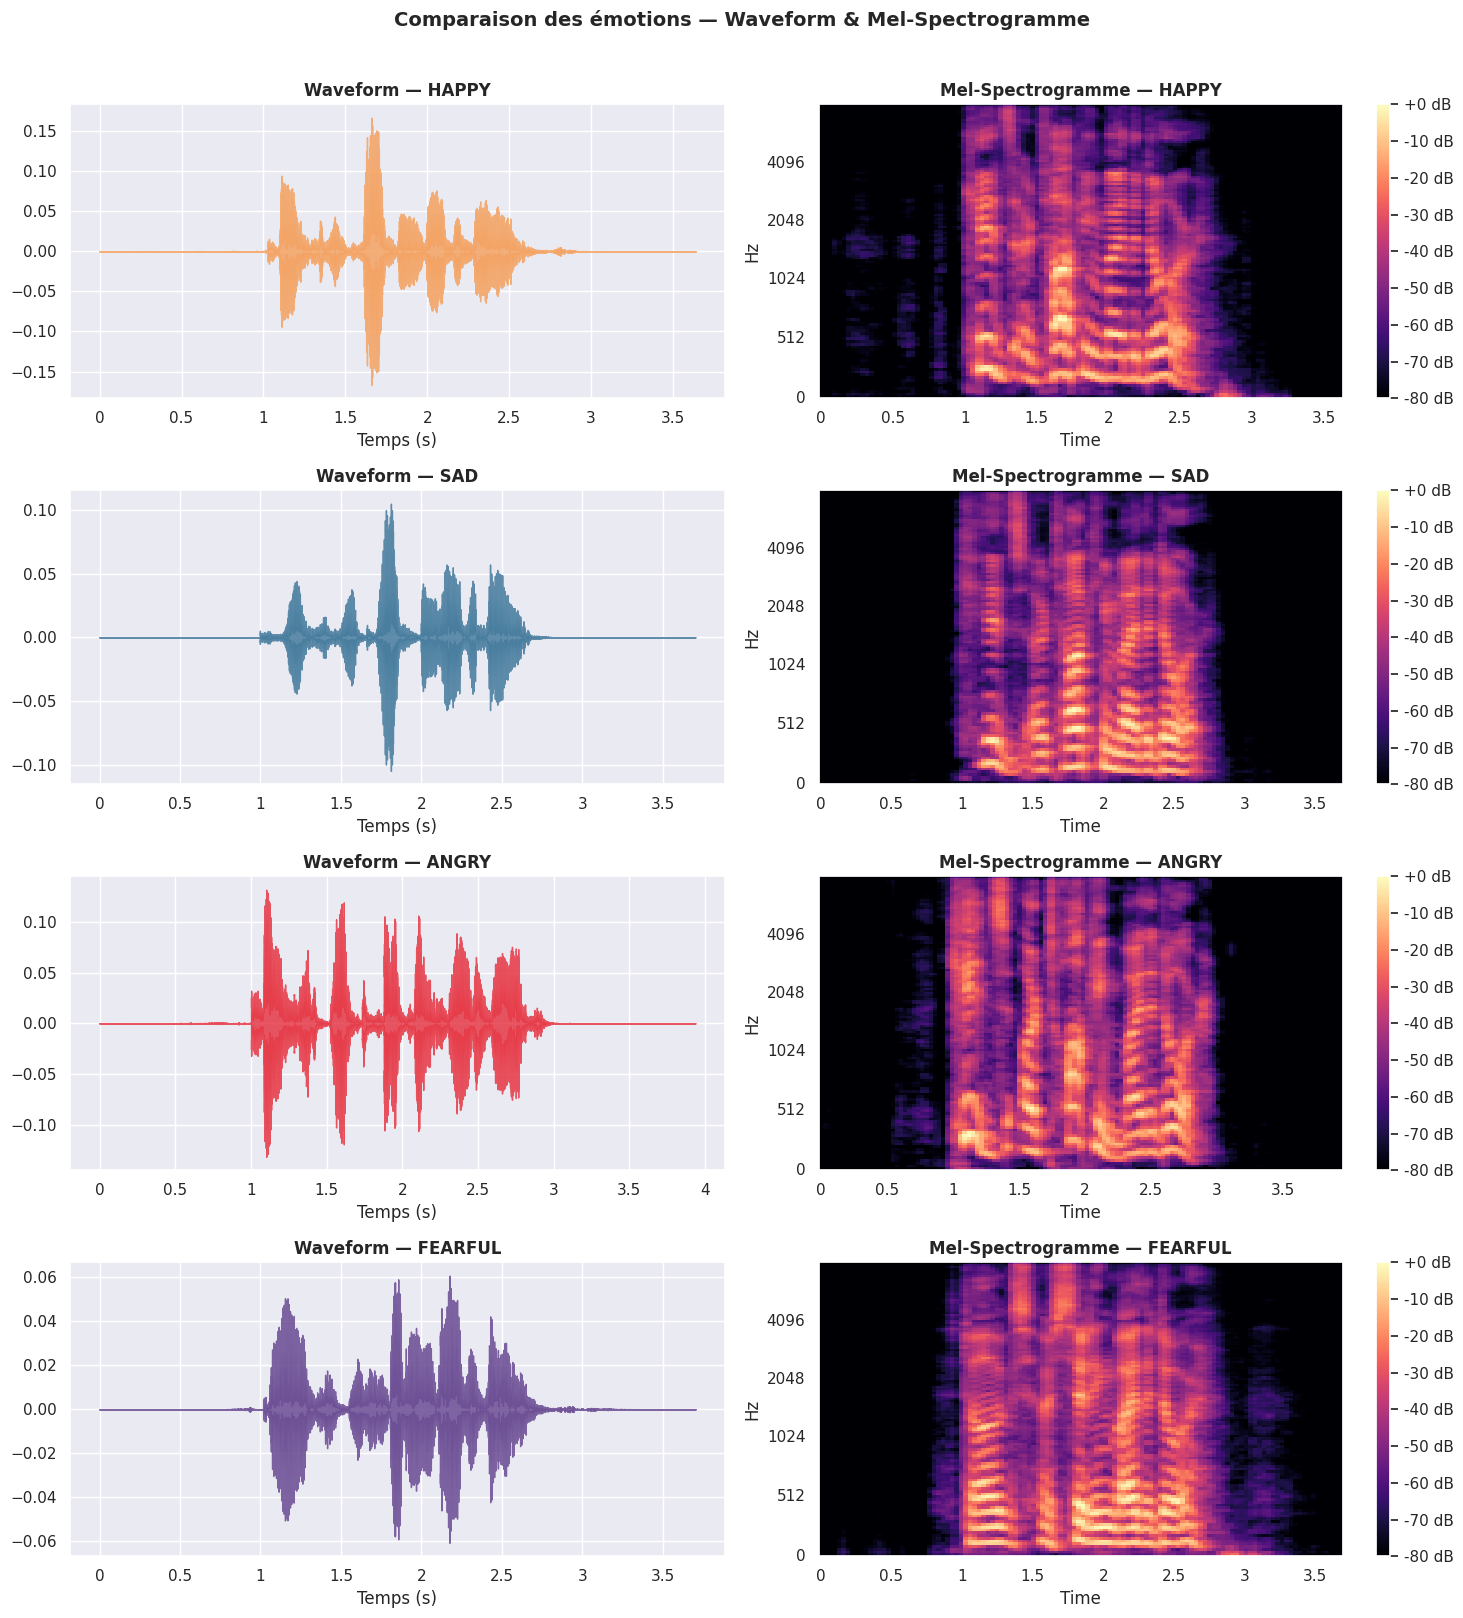

 Sauvegardé : comparaison_4_emotions.png


In [9]:
EMOTIONS_COMPARE = ['happy', 'sad', 'angry', 'fearful']
COLORS           = ['#f4a261', '#457b9d', '#e63946', '#6a4c93']
SR = 16000

fig, axes = plt.subplots(len(EMOTIONS_COMPARE), 2, figsize=(15, 4 * len(EMOTIONS_COMPARE)))
fig.suptitle('Comparaison des émotions — Waveform & Mel-Spectrogramme',
             fontsize=14, fontweight='bold', y=1.01)

for i, (emotion, color) in enumerate(zip(EMOTIONS_COMPARE, COLORS)):
    candidates = df[df['emotion'] == emotion]
    if candidates.empty:
        print(f'  Aucun fichier pour : {emotion}')
        continue

    path  = candidates.iloc[0]['path']
    audio, sr = librosa.load(path, sr=SR)

    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=axes[i][0], color=color, alpha=0.85)
    axes[i][0].set_title(f"Waveform — {emotion.upper()}", fontweight='bold')
    axes[i][0].set_xlabel('Temps (s)')

    # Mel-spectrogramme
    mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=sr, x_axis='time',
                                      y_axis='mel', ax=axes[i][1], cmap='magma')
    fig.colorbar(img, ax=axes[i][1], format='%+2.0f dB')
    axes[i][1].set_title(f'Mel-Spectrogramme — {emotion.upper()}', fontweight='bold')

plt.tight_layout()
plt.savefig('comparaison_4_emotions.png', bbox_inches='tight')
plt.show()
print(' Sauvegardé : comparaison_4_emotions.png')

---
##  Cellule 8 — Analyse MFCC moyenne par émotion

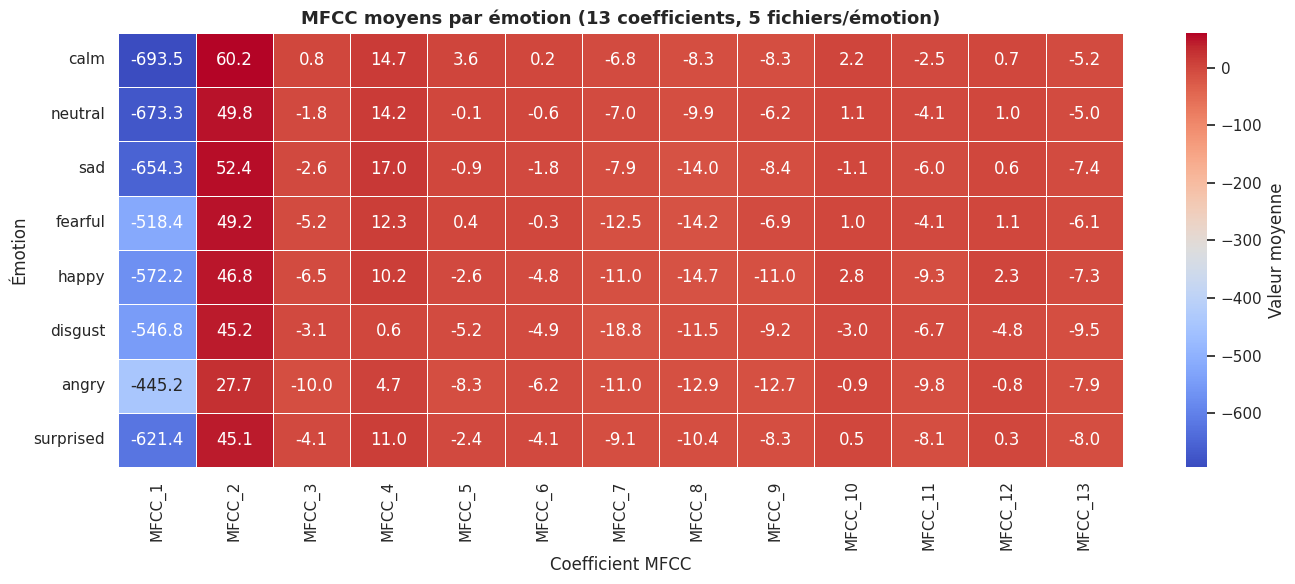

 Sauvegardé : mfcc_heatmap_emotions.png


In [10]:
SR      = 16000
N_MFCC  = 13
N_FILES = 5   # fichiers par émotion pour aller vite

mfcc_by_emotion = {}

for emotion in df['emotion'].unique():
    samples = df[df['emotion'] == emotion].head(N_FILES)
    mfccs   = []
    for path in samples['path']:
        audio, _ = librosa.load(path, sr=SR)
        mfcc     = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
        mfccs.append(np.mean(mfcc, axis=1))
    mfcc_by_emotion[emotion] = np.mean(mfccs, axis=0)

mfcc_df = pd.DataFrame(mfcc_by_emotion).T
mfcc_df.columns = [f'MFCC_{i+1}' for i in range(N_MFCC)]

plt.figure(figsize=(14, 6))
sns.heatmap(mfcc_df, annot=True, fmt='.1f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Valeur moyenne'})
plt.title(f'MFCC moyens par émotion ({N_MFCC} coefficients, {N_FILES} fichiers/émotion)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient MFCC')
plt.ylabel('Émotion')
plt.tight_layout()
plt.savefig('mfcc_heatmap_emotions.png', bbox_inches='tight')
plt.show()
print(' Sauvegardé : mfcc_heatmap_emotions.png')

---
##  Cellule 9 — Écoute interactive par émotion

In [12]:
SR = 16000

for emotion in sorted(df['emotion'].unique()):
    path  = df[df['emotion'] == emotion].iloc[0]['path']
    audio, _ = librosa.load(path, sr=SR)
    print(f' {emotion.upper()}')
    display(Audio(audio, rate=SR))

 ANGRY


 CALM


 DISGUST


 FEARFUL


 HAPPY


 NEUTRAL


 SAD


 SURPRISED


---
##  Cellule 10 — Résumé & prochaines étapes

In [21]:
print('=' * 55)
print('       RÉSUMÉ DE L\'EXPLORATION')
print('=' * 55)
print(f'  Fichiers totaux   : {len(df)}')
print(f'  Acteurs           : {df["actor"].nunique()}')
print(f'  Émotions          : {df["emotion"].nunique()}')
print(f'  Durée moyenne     : {df["duration"].mean():.2f}s')
print(f'  Durée min / max   : {df["duration"].min():.2f}s / {df["duration"].max():.2f}s')
print('=' * 55)



       RÉSUMÉ DE L'EXPLORATION
  Fichiers totaux   : 1440
  Acteurs           : 24
  Émotions          : 8
  Durée moyenne     : 3.70s
  Durée min / max   : 2.94s / 5.27s
